In [6]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [10]:
sys.path.insert(0, os.path.abspath("Bangladesh_flood/nasa_power_fetcher.py"))

from nasa_power_fetcher import (
    fetch_station,
    BANGLADESH_STATIONS,
    rainfall_summary,
)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#F8F8F8",
    "axes.grid":        True,
    "grid.alpha":       0.4,
    "font.size":        11,
})
print(f"Stations available: {list(BANGLADESH_STATIONS.keys())}")

Stations available: ['dhaka', 'chittagong', 'sylhet', 'rajshahi', 'khulna', 'barisal', 'rangpur', 'mymensingh']


##  Create folders

In [11]:
os.makedirs("../data/raw",       exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../models",         exist_ok=True)

print("✓ Folders created:")
print("  ../data/raw/        ← raw CSVs saved here")
print("  ../data/processed/  ← cleaned data goes here")
print("  ../models/          ← trained models saved here")

✓ Folders created:
  ../data/raw/        ← raw CSVs saved here
  ../data/processed/  ← cleaned data goes here
  ../models/          ← trained models saved here


## Set date range and station config

In [12]:
START_DATE = "2000-01-01"
END_DATE   = "2023-12-31"

# To test quickly, fetch only Dhaka first:
#   STATIONS_TO_FETCH = ["dhaka"]
# Set to None to fetch all 8 divisions
STATIONS_TO_FETCH = None

stations = (
    list(BANGLADESH_STATIONS.keys())
    if STATIONS_TO_FETCH is None
    else STATIONS_TO_FETCH
)

print(f"Date range : {START_DATE} → {END_DATE}")
print(f"Stations   : {stations}")
print(f"Expected rows per station : ~{(pd.Timestamp(END_DATE) - pd.Timestamp(START_DATE)).days:,} days")

Date range : 2000-01-01 → 2023-12-31
Stations   : ['dhaka', 'chittagong', 'sylhet', 'rajshahi', 'khulna', 'barisal', 'rangpur', 'mymensingh']
Expected rows per station : ~8,765 days


## Fetch Dhaka first as a sanity check

In [13]:
print("Fetching Dhaka (sanity check)...")
dhaka_test = fetch_station("dhaka", start=START_DATE, end=END_DATE)

print(f"\nShape      : {dhaka_test.shape}")
print(f"Date range : {dhaka_test.index.min().date()} → {dhaka_test.index.max().date()}")
print(f"Columns    : {list(dhaka_test.columns)}")
print(f"Missing    : {dhaka_test.isna().sum().to_dict()}")

dhaka_test.head(10)

2026-05-21 16:01:14,833 — INFO — Station: Dhaka | lat=23.8103, lon=90.4125
2026-05-21 16:01:14,834 — INFO — Fetching NASA POWER data | lat=23.8103, lon=90.4125 | 2000-01-01 → 2023-12-31


Fetching Dhaka (sanity check)...


2026-05-21 16:01:18,473 — INFO — ✓ Fetched 8766 days | 0 missing values filled with NaN



Shape      : (8766, 5)
Date range : 2000-01-01 → 2023-12-31
Columns    : ['rainfall_mm', 'temp_c', 'humidity_pct', 'wind_speed_ms', 'station']
Missing    : {'rainfall_mm': 0, 'temp_c': 0, 'humidity_pct': 0, 'wind_speed_ms': 0, 'station': 0}


,rainfall_mm,temp_c,humidity_pct,wind_speed_ms,station
date,,,,,
2000-01-01,0.0,17.56,68.01,2.58,dhaka
2000-01-02,0.0,17.46,66.91,2.16,dhaka
2000-01-03,0.0,17.20,62.91,2.37,dhaka
2000-01-04,0.0,16.99,62.36,3.07,dhaka
2000-01-05,0.0,16.97,63.31,2.63,dhaka
2000-01-06,0.0,16.82,62.10,2.47,dhaka
2000-01-07,0.0,16.37,62.50,2.98,dhaka
2000-01-08,0.0,15.57,56.85,2.57,dhaka
2000-01-09,0.0,16.27,57.81,2.54,dhaka


##  Plot Dhaka to verify monsoon pattern is visible

2026-05-21 16:02:18,039 — INFO — Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-21 16:02:18,039 — INFO — Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


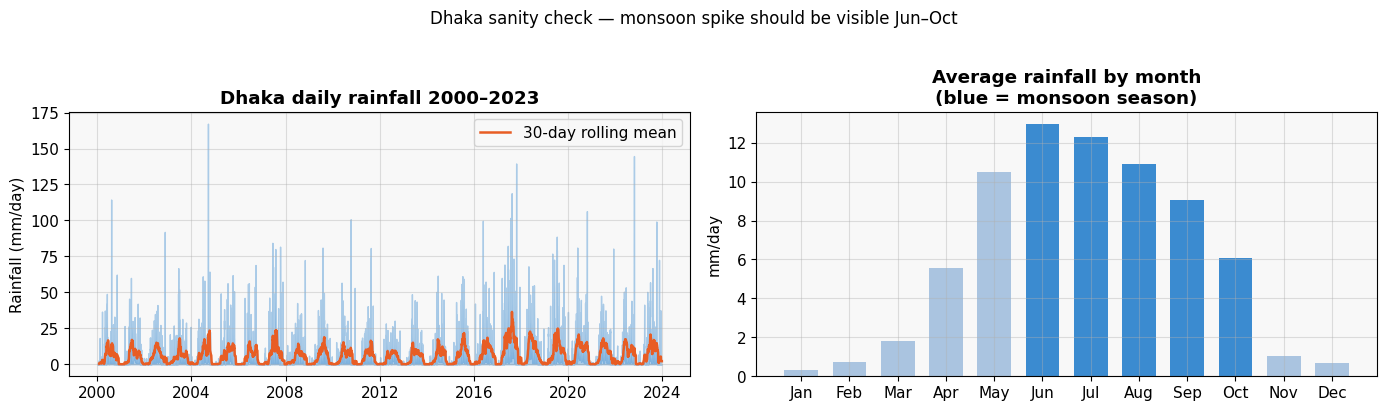

✓ Expected: spike in Jun–Sep, near-zero Nov–Mar


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left — full time series
ax = axes[0]
ax.fill_between(dhaka_test.index, dhaka_test["rainfall_mm"], alpha=0.4, color="#3B8BD0")
ax.plot(dhaka_test.index,
        dhaka_test["rainfall_mm"].rolling(30).mean(),
        color="#E85D24", lw=1.8, label="30-day rolling mean")
ax.set_title("Dhaka daily rainfall 2000–2023", fontweight="bold")
ax.set_ylabel("Rainfall (mm/day)")
ax.legend()

# Right — monthly average (monsoon should spike Jun–Oct)
ax = axes[1]
monthly_avg = dhaka_test["rainfall_mm"].groupby(dhaka_test.index.month).mean()
month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
colours = ["#3B8BD0" if m in [6,7,8,9,10] else "#AAC4E0"
           for m in range(1, 13)]
ax.bar(month_names, monthly_avg.values, color=colours, width=0.7)
ax.set_title("Average rainfall by month\n(blue = monsoon season)", fontweight="bold")
ax.set_ylabel("mm/day")

plt.suptitle("Dhaka sanity check — monsoon spike should be visible Jun–Oct",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


print("✓ Expected: spike in Jun–Sep, near-zero Nov–Mar")

## Fetch all 8 divisions and save CSVs

In [15]:
RUN_FETCH = True

all_data = {}

if RUN_FETCH:
    for station in stations:
        print(f"Fetching {station.title()}...")
        try:
            df = fetch_station(station, start=START_DATE, end=END_DATE)
            df["station"] = station
            all_data[station] = df

            path = f"../data/raw/{station}.csv"
            df.to_csv(path)
            print(f"  ✓ {len(df):,} rows saved → {path}\n")

        except Exception as e:
            print(f"  ✗ {station} failed: {e} — skipping\n")

    print(f"✓ Done — fetched {len(all_data)}/{len(stations)} stations")

else:
    # Load from disk if already fetched
    for station in stations:
        path = f"../data/raw/{station}.csv"
        if os.path.exists(path):
            all_data[station] = pd.read_csv(
                path, index_col="date", parse_dates=True
            )
            print(f"  Loaded {station} from disk")
    print(f"\n✓ Loaded {len(all_data)} stations from disk")

2026-05-21 16:03:09,834 — INFO — Station: Dhaka | lat=23.8103, lon=90.4125
2026-05-21 16:03:09,835 — INFO — Fetching NASA POWER data | lat=23.8103, lon=90.4125 | 2000-01-01 → 2023-12-31


Fetching Dhaka...


2026-05-21 16:03:13,161 — INFO — ✓ Fetched 8766 days | 0 missing values filled with NaN
2026-05-21 16:03:13,207 — INFO — Station: Chittagong | lat=22.3475, lon=91.8123
2026-05-21 16:03:13,208 — INFO — Fetching NASA POWER data | lat=22.3475, lon=91.8123 | 2000-01-01 → 2023-12-31


  ✓ 8,766 rows saved → ../data/raw/dhaka.csv

Fetching Chittagong...


2026-05-21 16:03:16,069 — INFO — ✓ Fetched 8766 days | 0 missing values filled with NaN
2026-05-21 16:03:16,101 — INFO — Station: Sylhet | lat=24.8949, lon=91.8687
2026-05-21 16:03:16,101 — INFO — Fetching NASA POWER data | lat=24.8949, lon=91.8687 | 2000-01-01 → 2023-12-31


...

  ✓ 8,766 rows saved → ../data/raw/barisal.csv

Fetching Rangpur...


2026-05-21 16:03:31,866 — INFO — ✓ Fetched 8766 days | 0 missing values filled with NaN
2026-05-21 16:03:31,905 — INFO — Station: Mymensingh | lat=24.7471, lon=90.4203
2026-05-21 16:03:31,908 — INFO — Fetching NASA POWER data | lat=24.7471, lon=90.4203 | 2000-01-01 → 2023-12-31


  ✓ 8,766 rows saved → ../data/raw/rangpur.csv

Fetching Mymensingh...


2026-05-21 16:03:34,960 — INFO — ✓ Fetched 8766 days | 0 missing values filled with NaN


  ✓ 8,766 rows saved → ../data/raw/mymensingh.csv

✓ Done — fetched 8/8 stations


## Data quality check

In [16]:
# Check each station for missing values, date gaps, and basic stats
rows = []

for station, df in all_data.items():
    full_range    = pd.date_range(df.index.min(), df.index.max(), freq="D")
    missing_dates = len(full_range.difference(df.index))

    rows.append({
        "station":        station,
        "total_days":     len(df),
        "date_gaps":      missing_dates,
        "nan_rainfall":   int(df["rainfall_mm"].isna().sum()),
        "nan_temp":       int(df["temp_c"].isna().sum()),
        "zero_rain_days": int((df["rainfall_mm"] == 0).sum()),
        "max_rain_mm":    round(df["rainfall_mm"].max(), 1),
        "mean_rain_mm":   round(df["rainfall_mm"].mean(), 2),
    })

quality_df = pd.DataFrame(rows).set_index("station")
quality_df.to_csv("../data/raw/data_quality_report.csv")
print("Data quality report:\n")
quality_df

Data quality report:



,total_days,date_gaps,nan_rainfall,nan_temp,zero_rain_days,max_rain_mm,mean_rain_mm
station,,,,,,,
dhaka,8766,0,0,0,3053,167.3,6.02
chittagong,8766,0,0,0,3469,395.8,8.28
sylhet,8766,0,0,0,2990,279.9,10.48
rajshahi,8766,0,0,0,3268,98.1,3.87
khulna,8766,0,0,0,3274,244.3,4.90
barisal,8766,0,0,0,3169,272.1,7.79
rangpur,8766,0,0,0,3139,160.0,5.44
mymensingh,8766,0,0,0,2989,171.7,6.94


## Handle missing values

In [22]:
# NASA POWER rarely has gaps but we handle them cleanly
cleaned_data = {}

for station, df in all_data.items():

    df_clean = df.copy()

    # Ensure index is datetime
    df_clean.index = pd.to_datetime(df_clean.index)

    # Numeric columns only
    numeric_cols = df_clean.select_dtypes(include=["number"]).columns

    # Forward fill short gaps
    df_clean[numeric_cols] = df_clean[numeric_cols].ffill(limit=2)

    # Time interpolation
    df_clean[numeric_cols] = df_clean[numeric_cols].interpolate(
        method="time",
        limit=7
    )

    # Rainfall cannot be negative
    if "rainfall_mm" in df_clean.columns:
        df_clean["rainfall_mm"] = df_clean["rainfall_mm"].clip(lower=0)

    # Drop remaining NaN
    df_clean = df_clean.dropna()

    cleaned_data[station] = df_clean

    # Save CSV
    df_clean.to_csv(
        f"../data/processed/{station}_clean.csv"
    )

print("Missing values after cleaning:\n")

for station, df in cleaned_data.items():
    print(
        f"{station:12}: "
        f"{df.isna().sum().sum()} NaN remaining | "
        f"{len(df):,} rows kept"
    )

print("\n✓ Clean CSVs saved → ../data/processed/<station>_clean.csv")

Missing values after cleaning:

dhaka       : 0 NaN remaining | 8,766 rows kept
chittagong  : 0 NaN remaining | 8,766 rows kept
sylhet      : 0 NaN remaining | 8,766 rows kept
rajshahi    : 0 NaN remaining | 8,766 rows kept
khulna      : 0 NaN remaining | 8,766 rows kept
barisal     : 0 NaN remaining | 8,766 rows kept
rangpur     : 0 NaN remaining | 8,766 rows kept
mymensingh  : 0 NaN remaining | 8,766 rows kept

✓ Clean CSVs saved → ../data/processed/<station>_clean.csv


## Plot all 8 stations overview

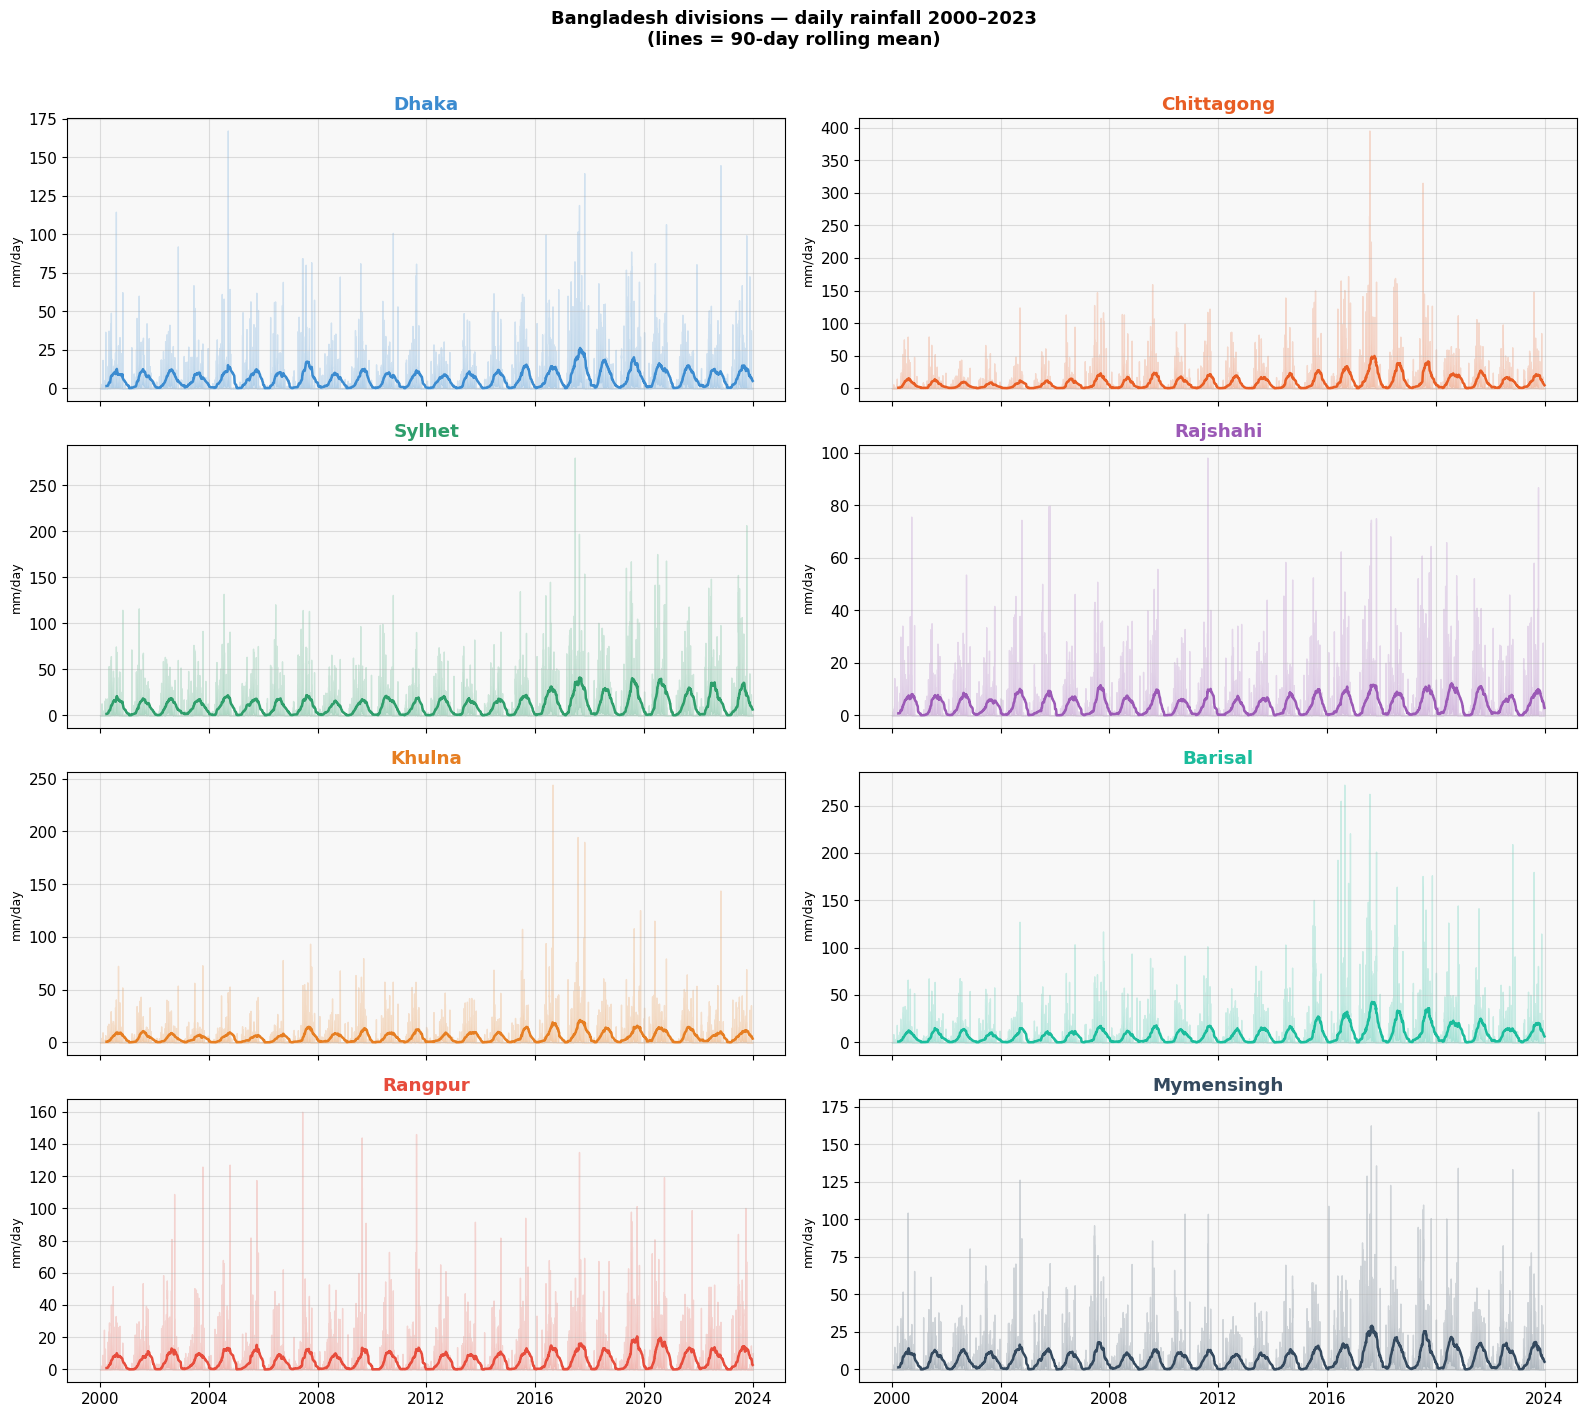

✓ Plot saved → ../data/raw/all_stations_overview.png


In [23]:
palette = ["#3B8BD0","#E85D24","#2E9E6B","#9B59B6",
           "#E67E22","#1ABC9C","#E74C3C","#34495E"]

fig, axes = plt.subplots(4, 2, figsize=(16, 14), sharex=True)
axes = axes.flatten()

for i, (station, df) in enumerate(cleaned_data.items()):
    ax  = axes[i]
    col = palette[i]
    roll = df["rainfall_mm"].rolling(90).mean()

    ax.fill_between(df.index, df["rainfall_mm"], alpha=0.2, color=col)
    ax.plot(df.index, roll, color=col, lw=1.8)

    ax.set_title(station.title(), fontweight="bold", color=col)
    ax.set_ylabel("mm/day", fontsize=9)

plt.suptitle("Bangladesh divisions — daily rainfall 2000–2023\n(lines = 90-day rolling mean)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../data/raw/all_stations_overview.png", dpi=130, bbox_inches="tight")
plt.show()
print("✓ Plot saved → ../data/raw/all_stations_overview.png")

## Monthly summary table

In [24]:
month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

summary = {}
for station, df in cleaned_data.items():
    summary[station] = (
        df["rainfall_mm"]
        .groupby(df.index.month)
        .mean()
        .round(1)
        .values
    )

summary_df = pd.DataFrame(summary, index=month_names).T
summary_df.to_csv("../data/processed/monthly_summary.csv")
print("Average daily rainfall (mm/day) by month:\n")
summary_df

Average daily rainfall (mm/day) by month:



,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
dhaka,0.3,0.7,1.8,5.5,10.5,12.9,12.3,10.9,9.0,6.1,1.0,0.7
chittagong,0.3,0.6,1.4,3.9,9.9,19.0,23.2,17.6,13.0,7.7,1.8,0.6
sylhet,0.4,1.1,3.4,12.4,17.9,25.3,21.9,19.0,14.3,8.1,0.8,0.7
rajshahi,0.2,0.5,0.8,2.6,5.5,7.5,8.8,7.7,7.6,4.5,0.3,0.3
khulna,0.3,0.8,1.1,2.5,6.6,9.5,11.6,10.4,8.5,5.8,1.0,0.6
barisal,0.3,0.8,1.5,3.6,9.0,16.5,20.9,16.6,12.3,8.6,2.2,0.7
rangpur,0.2,0.5,1.0,4.1,8.3,12.0,11.8,10.5,10.4,5.7,0.2,0.2
mymensingh,0.4,0.8,2.1,6.9,12.2,15.6,14.1,12.4,10.4,6.7,0.8,0.6


In [25]:
print("=" * 50)
print("  notebook_01 complete!")
print("=" * 50)
print()

all_files = []
for folder in ["../data/raw", "../data/processed"]:
    for f in os.listdir(folder):
        if f.endswith(".csv"):
            full = os.path.join(folder, f)
            kb   = os.path.getsize(full) / 1024
            all_files.append((full, kb))

print("Files saved:")
for path, kb in sorted(all_files):
    print(f"  {path:<45} {kb:>7.1f} KB")

print()
print("Next: open notebook_02_eda.ipynb")
print("Load data with:")
print('  df = pd.read_csv("../data/processed/dhaka_clean.csv",')
print('                   index_col="date", parse_dates=True)')

  notebook_01 complete!

Files saved:
  ../data/processed\barisal_clean.csv             355.3 KB
  ../data/processed\chittagong_clean.csv          380.9 KB
  ../data/processed\dhaka_clean.csv               338.0 KB
  ../data/processed\khulna_clean.csv              346.1 KB
  ../data/processed\monthly_summary.csv             0.5 KB
  ../data/processed\mymensingh_clean.csv          381.3 KB
  ../data/processed\rajshahi_clean.csv            363.0 KB
  ../data/processed\rangpur_clean.csv             355.0 KB
  ../data/processed\sylhet_clean.csv              347.7 KB
  ../data/raw\barisal.csv                         355.3 KB
  ../data/raw\chittagong.csv                      380.9 KB
  ../data/raw\data_quality_report.csv               0.4 KB
  ../data/raw\dhaka.csv                           338.0 KB
  ../data/raw\khulna.csv                          346.1 KB
  ../data/raw\mymensingh.csv                      381.3 KB
  ../data/raw\rajshahi.csv                        363.0 KB
  ../data/raw\rang